XGBoost (Extreme Gradient Boosting)

a powerful and high‑performance machine learning model used for classification and regression tasks. 
XGBoost builds a series of decision trees where each new tree corrects errors made by earlier trees. 
It’s widely used in real ML problems because of its performance and speed


Using real dataset (Pima Indians Diabetes-classic for classification)
We will be loading data, inspecting, cleaning, training, testing and evaluating the model.

1) Install XGBoost and Required Libraries

In [1]:
!pip install xgboost pandas scikit-learn matplotlib seaborn


   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/72.0 MB 882.6 kB/s eta 0:01:21
   ---------------------------------------- 0.8/72.0 MB 1.1 MB/s eta 0:01:04
   - -------------------------------------- 2.1/72.0 MB 2.4 MB/s eta 0:00:30
   - -------------------------------------- 2.9/72.0 MB 2.9 MB/s eta 0:00:24
   --- ------------------------------------ 6.0/72.0 MB 4.4 MB/s eta 0:00:15
   --- ------------------------------------ 7.1/72.0 MB 4.7 MB/s eta 0:00:14
   ---- ----------------------------------- 8.1/72.0 MB 4.6 MB/s eta 0:00:14
   ----- ---------------------------------- 10.0/72.0 MB 4.9 MB/s eta 0:00:13
   ------ --------------------------------- 11.3/72.0 MB 5.0 MB/s eta 0:00:13
   ------ -------------


2) Import Libraries
 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from xgboost import XGBClassifier


3) Load Real Dataset (Pima Indians Diabetes)

We’ll use a dataset from GitHub that contains medical predictor variables and a target indicating if the person has diabetes.

In [4]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
column_names = [
    'Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin',
    'BMI','DiabetesPedigreeFunction','Age','Outcome'
]
df = pd.read_csv(url, names=column_names)
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


4) Inspect & Clean Data

Check missing values and basic stats:

This dataset doesn’t have explicit missing values encoded, but some rows may have 0 values for physically impossible measurements (e.g., 0 for BloodPressure). 
We’ll leave it for simplicity here.

print(df.isnull().sum())
df.describe()



5) Split Features & Target


In [5]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



6) Train XGBoost Classifier


In [6]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f


7) Test / Predictions
 

In [7]:
y_pred = model.predict(X_test)



8) Evaluate the Model
✅ Accuracy


In [8]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")


Accuracy: 0.747


In [9]:

#Classification Report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.77      0.80        99
           1       0.63      0.71      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



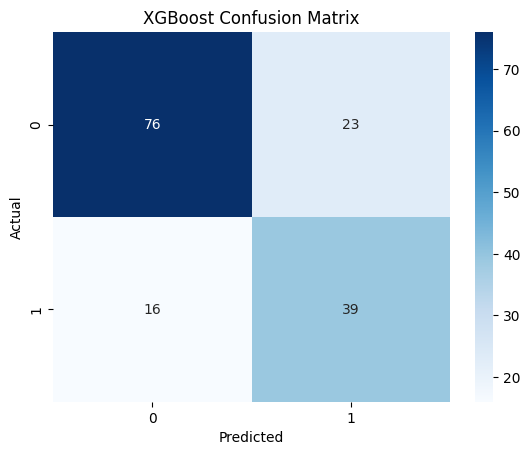

In [10]:

#Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()


Feature Importance Visualization

XGBoost can tell which features mattered most:



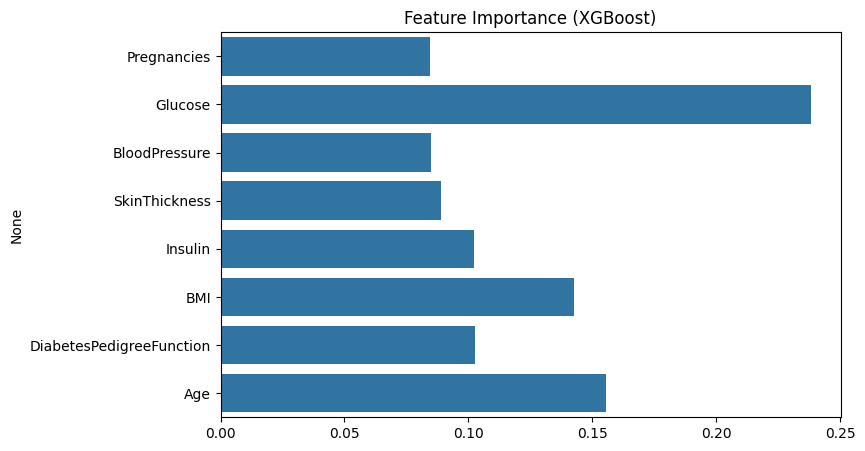

In [11]:
importances = model.feature_importances_
feat_names = X.columns

plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=feat_names)
plt.title("Feature Importance (XGBoost)")
plt.show()
